# Notebook 03 — Generalización, underfitting, overfitting y sesgo-varianza

En este notebook estudiaremos por qué un modelo que ajusta muy bien los datos de entrenamiento puede predecir mal sobre observaciones nuevas.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- distinguir entre ajuste y generalización;
- identificar underfitting y overfitting;
- relacionar complejidad, error de entrenamiento y error de prueba;
- visualizar el compromiso entre sesgo y varianza;
- analizar el efecto del tamaño de muestra;
- utilizar curvas de aprendizaje;
- comprender por qué la selección de modelos debe realizarse con datos no utilizados durante el ajuste.

Usaremos una relación sintética no lineal para comparar modelos polinomiales con distintos grados.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Proceso generador de los datos

Utilizaremos una función verdadera no lineal:

\[
f(x)=\sin(1.5x)+0.3x.
\]

Las observaciones incluyen ruido:

\[
y=f(x)+\varepsilon.
\]

Como conocemos \(f(x)\), podremos comparar lo que aprende cada modelo con la relación verdadera.

In [2]:
def true_function(x):
    """Función verdadera utilizada para generar la variable objetivo."""
    return np.sin(1.5 * x) + 0.3 * x


n_samples = 120

X = rng.uniform(-3, 3, size=(n_samples, 1))
noise = rng.normal(0, 0.35, size=n_samples)
y = true_function(X[:, 0]) + noise

data = pd.DataFrame({
    "x": X[:, 0],
    "y": y,
})

data.head()


,x,y
0,1.6437,1.6794
1,-0.3667,-0.7166
2,2.1516,0.2016
3,1.1842,1.3970
4,-2.4349,-0.1646


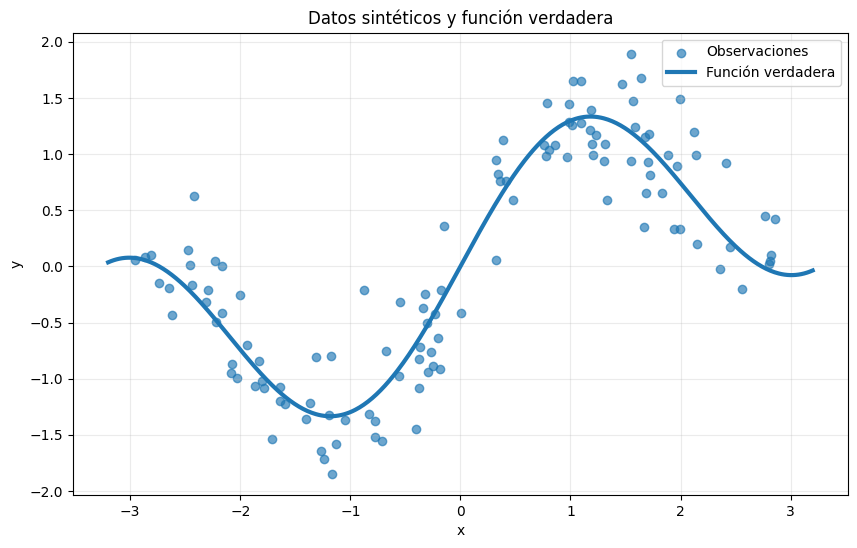

In [3]:
x_grid = np.linspace(-3.2, 3.2, 500)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, alpha=0.65, label="Observaciones")
plt.plot(x_grid, true_function(x_grid), linewidth=3, label="Función verdadera")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos y función verdadera")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 3. Split de entrenamiento y prueba

El conjunto de entrenamiento se utilizará para estimar cada modelo. El conjunto de prueba permitirá aproximar su capacidad de generalización.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.35,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {len(X_train)} observaciones")
print(f"Prueba: {len(X_test)} observaciones")


Entrenamiento: 78 observaciones
Prueba: 42 observaciones


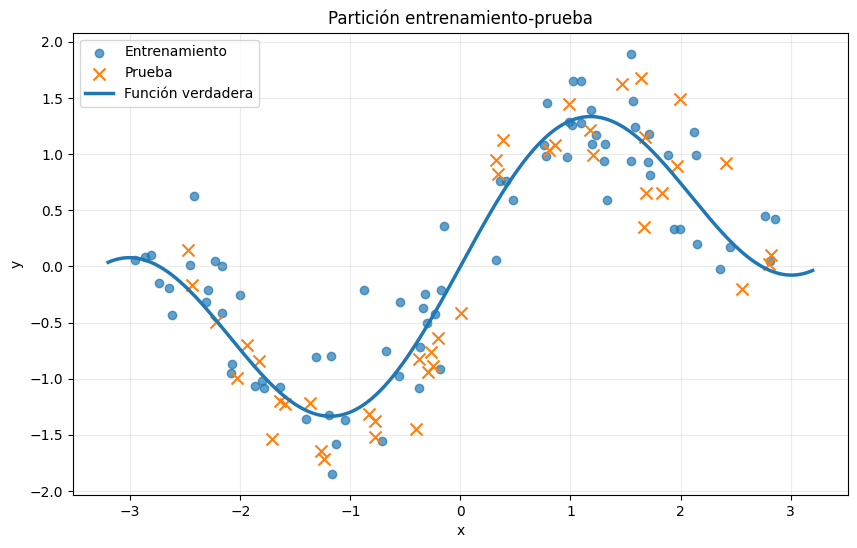

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.7, label="Entrenamiento")
plt.scatter(X_test[:, 0], y_test, marker="x", s=75, label="Prueba")
plt.plot(x_grid, true_function(x_grid), linewidth=2.5, label="Función verdadera")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Partición entrenamiento-prueba")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Modelos polinomiales

Un modelo polinomial de grado \(d\) amplía la representación original:

\[
x \longrightarrow (x,x^2,\ldots,x^d).
\]

Después ajusta una regresión lineal sobre esas variables transformadas.

Compararemos grados bajos, intermedios y muy altos.

In [6]:
def build_polynomial_model(degree):
    """Construye un pipeline de regresión polinomial."""
    return Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree=degree,
            include_bias=False,
        )),
        ("linear_regression", LinearRegression()),
    ])


degrees_to_show = [1, 3, 8, 15]
models = {}

for degree in degrees_to_show:
    model = build_polynomial_model(degree)
    model.fit(X_train, y_train)
    models[degree] = model


## 5. Underfitting, buen ajuste y overfitting

Observaremos las funciones aprendidas por modelos de distinta complejidad.

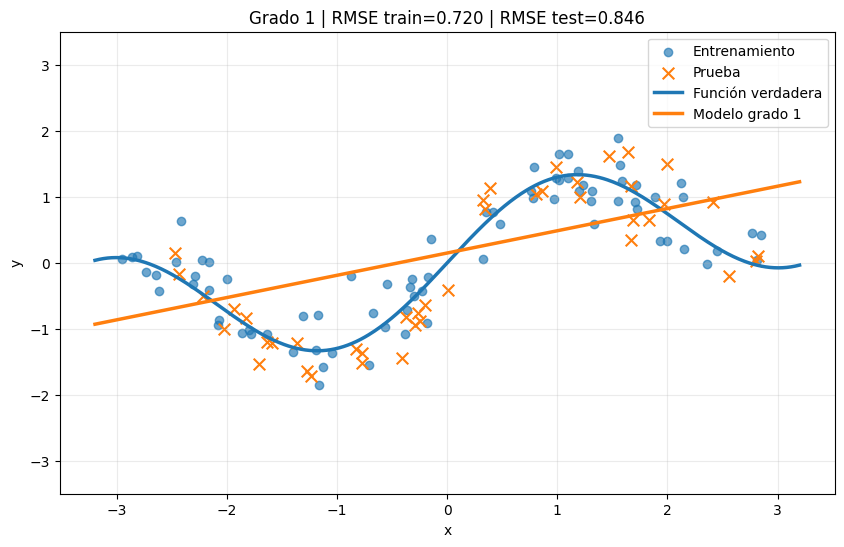

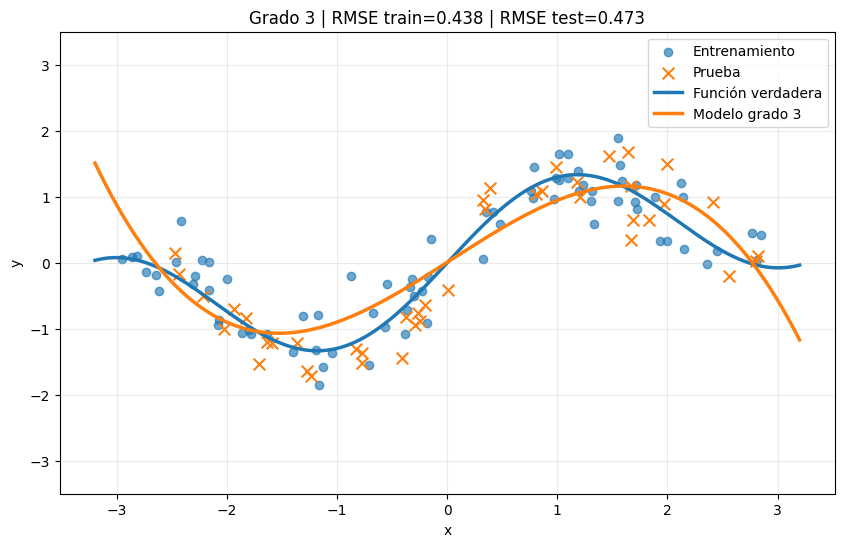

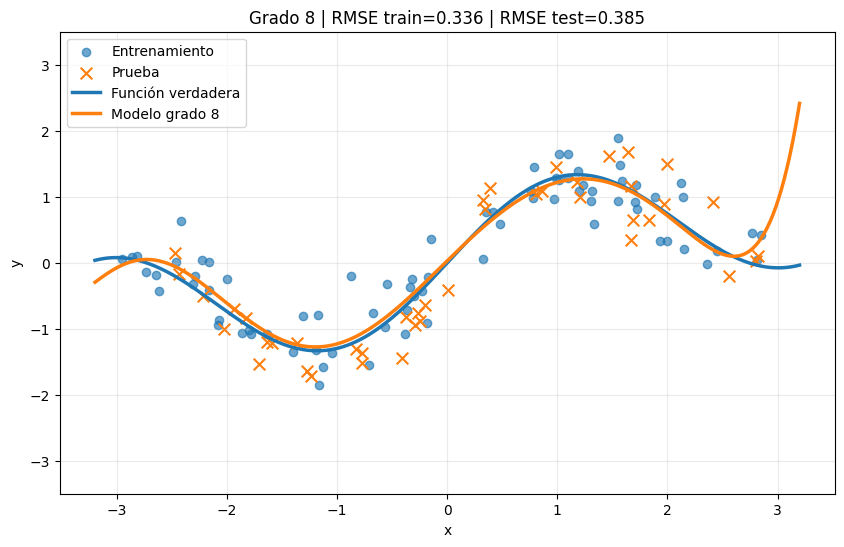

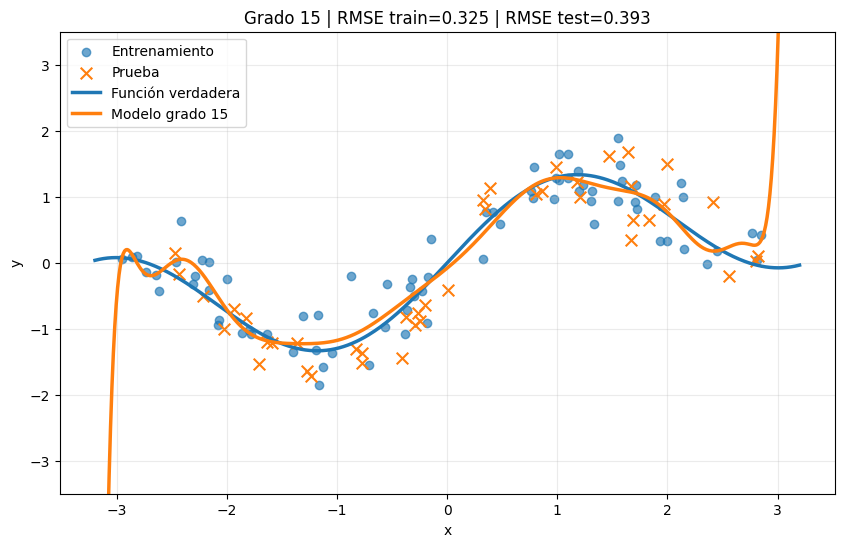

In [7]:
for degree, model in models.items():
    y_grid_pred = model.predict(x_grid.reshape(-1, 1))

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
    test_rmse = mean_squared_error(y_test, test_pred) ** 0.5

    plt.figure(figsize=(10, 6))
    plt.scatter(X_train[:, 0], y_train, alpha=0.65, label="Entrenamiento")
    plt.scatter(X_test[:, 0], y_test, marker="x", s=70, label="Prueba")
    plt.plot(x_grid, true_function(x_grid), linewidth=2.5, label="Función verdadera")
    plt.plot(
        x_grid,
        y_grid_pred,
        linewidth=2.5,
        label=f"Modelo grado {degree}",
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"Grado {degree} | RMSE train={train_rmse:.3f} | "
        f"RMSE test={test_rmse:.3f}"
    )
    plt.ylim(-3.5, 3.5)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


### Interpretación

- **Underfitting:** el modelo es demasiado rígido para capturar la estructura.
- **Ajuste razonable:** el modelo captura la señal sin perseguir excesivamente el ruido.
- **Overfitting:** el modelo aprende detalles accidentales de la muestra de entrenamiento.

El overfitting no significa simplemente que el modelo sea complejo. Significa que la complejidad utilizada no se traduce en mejor desempeño fuera de muestra.

## 6. Error de entrenamiento y prueba según la complejidad

Aumentaremos el grado polinomial y registraremos el RMSE de entrenamiento y prueba.

In [8]:
degrees = range(1, 21)
results = []

for degree in degrees:
    model = build_polynomial_model(degree)
    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    results.append({
        "grado": degree,
        "rmse_train": mean_squared_error(
            y_train,
            train_prediction,
        ) ** 0.5,
        "rmse_test": mean_squared_error(
            y_test,
            test_prediction,
        ) ** 0.5,
    })

complexity_results = pd.DataFrame(results)
complexity_results


,grado,rmse_train,rmse_test
0,1,0.7198,0.8457
1,2,0.7110,0.8397
2,3,0.4375,0.4730
3,4,0.4357,0.4717
4,5,0.3370,0.3819
5,6,0.3370,0.3825
6,7,0.3370,0.3832
7,8,0.3365,0.3850
8,9,0.3351,0.3921
9,10,0.3308,0.3833


In [9]:
best_degree_row = complexity_results.loc[
    complexity_results["rmse_test"].idxmin()
]

print(f"Mejor grado según test: {int(best_degree_row['grado'])}")
print(f"RMSE de prueba mínimo: {best_degree_row['rmse_test']:.4f}")


Mejor grado según test: 11
RMSE de prueba mínimo: 0.3813


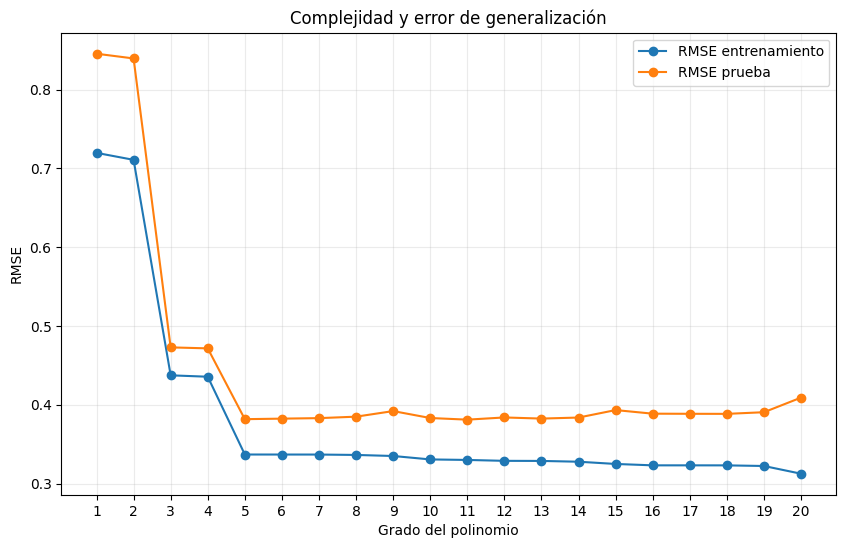

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    complexity_results["grado"],
    complexity_results["rmse_train"],
    marker="o",
    label="RMSE entrenamiento",
)

plt.plot(
    complexity_results["grado"],
    complexity_results["rmse_test"],
    marker="o",
    label="RMSE prueba",
)

plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Complejidad y error de generalización")
plt.xticks(list(degrees))
plt.legend()
plt.grid(alpha=0.25)
plt.show()


La curva suele mostrar tres regiones:

1. **Complejidad insuficiente:** errores altos en entrenamiento y prueba.
2. **Complejidad apropiada:** el error de prueba alcanza su mínimo.
3. **Complejidad excesiva:** el entrenamiento sigue mejorando, pero la prueba empeora.

> **Nota didáctica:** aquí usamos el test para visualizar el fenómeno. En un proyecto real, el grado debe seleccionarse con validación o validación cruzada, y el test debe reservarse para la evaluación final.

## 7. Una aproximación empírica al sesgo y la varianza

Entrenaremos repetidamente modelos sobre diferentes muestras generadas por el mismo proceso.

Para un punto fijo \(x_0\):

- el **sesgo** refleja la diferencia entre la predicción promedio y el valor verdadero;
- la **varianza** refleja cuánto cambian las predicciones entre muestras.

In [11]:
def generate_sample(
    n=35,
    noise_std=0.35,
    seed=None,
):
    local_rng = np.random.default_rng(seed)
    X_sample = local_rng.uniform(-3, 3, size=(n, 1))
    y_sample = (
        true_function(X_sample[:, 0])
        + local_rng.normal(0, noise_std, size=n)
    )
    return X_sample, y_sample


degrees_bias_variance = [1, 3, 15]
n_repetitions = 250
x_evaluation = np.linspace(-2.8, 2.8, 120).reshape(-1, 1)
true_values = true_function(x_evaluation[:, 0])

prediction_store = {
    degree: []
    for degree in degrees_bias_variance
}

for repetition in range(n_repetitions):
    X_sample, y_sample = generate_sample(
        n=35,
        seed=1_000 + repetition,
    )

    for degree in degrees_bias_variance:
        model = build_polynomial_model(degree)
        model.fit(X_sample, y_sample)
        prediction_store[degree].append(
            model.predict(x_evaluation)
        )


In [12]:
bias_variance_results = []

for degree, predictions in prediction_store.items():
    prediction_matrix = np.vstack(predictions)

    average_prediction = prediction_matrix.mean(axis=0)
    prediction_variance = prediction_matrix.var(axis=0)

    squared_bias = np.mean(
        (average_prediction - true_values) ** 2
    )
    average_variance = np.mean(prediction_variance)

    bias_variance_results.append({
        "grado": degree,
        "sesgo_cuadrado_aprox": squared_bias,
        "varianza_aprox": average_variance,
    })

bias_variance_table = pd.DataFrame(bias_variance_results)
bias_variance_table


,grado,sesgo_cuadrado_aprox,varianza_aprox
0,1,0.4490,0.0321
1,3,0.0532,0.0265
2,15,93.9756,"86,559.5179"


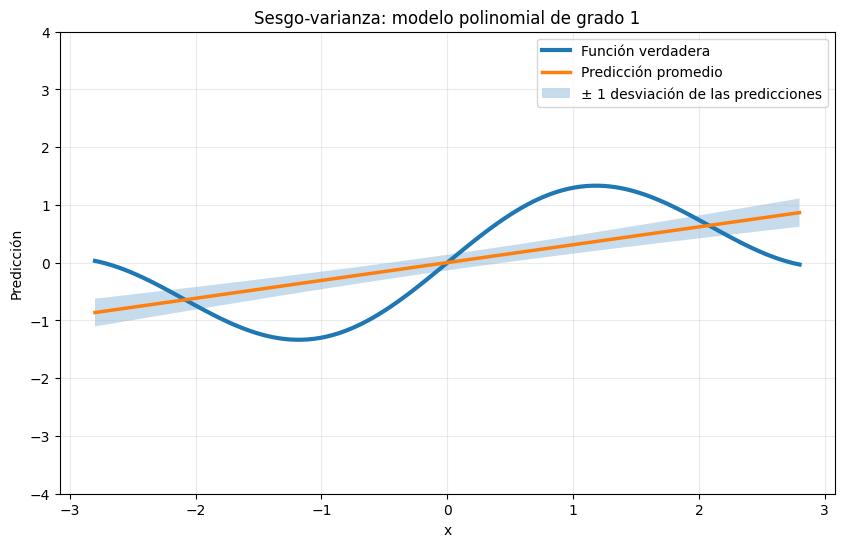

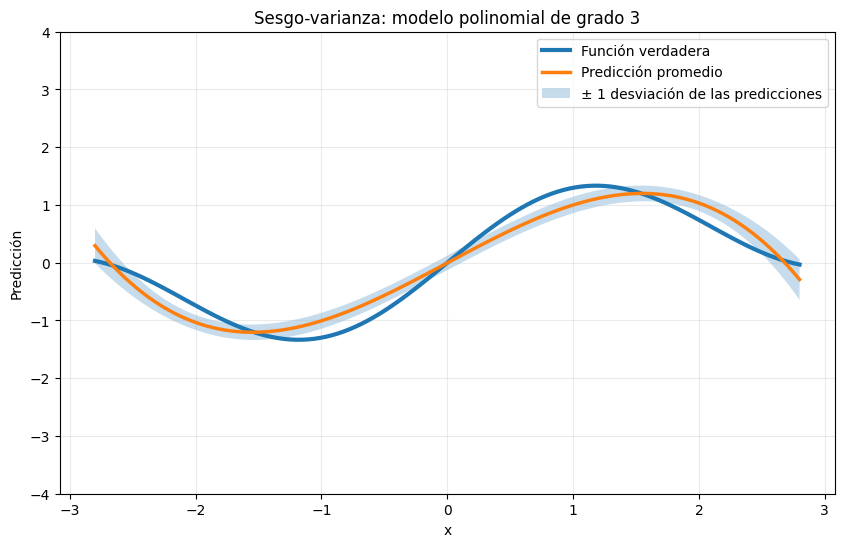

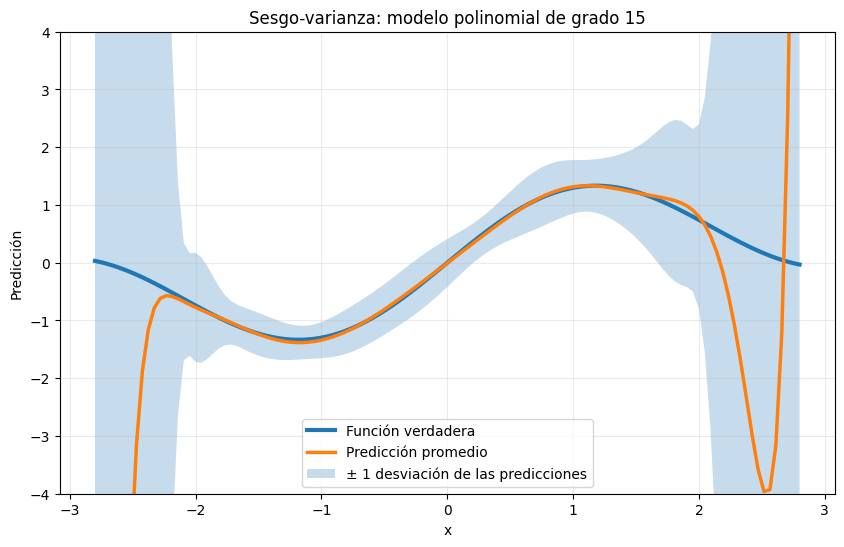

In [13]:
for degree in degrees_bias_variance:
    prediction_matrix = np.vstack(prediction_store[degree])

    average_prediction = prediction_matrix.mean(axis=0)
    prediction_std = prediction_matrix.std(axis=0)

    plt.figure(figsize=(10, 6))

    plt.plot(
        x_evaluation[:, 0],
        true_values,
        linewidth=3,
        label="Función verdadera",
    )

    plt.plot(
        x_evaluation[:, 0],
        average_prediction,
        linewidth=2.5,
        label="Predicción promedio",
    )

    plt.fill_between(
        x_evaluation[:, 0],
        average_prediction - prediction_std,
        average_prediction + prediction_std,
        alpha=0.25,
        label="± 1 desviación de las predicciones",
    )

    plt.xlabel("x")
    plt.ylabel("Predicción")
    plt.title(f"Sesgo-varianza: modelo polinomial de grado {degree}")
    plt.ylim(-4, 4)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


### Lectura conceptual

- Un modelo simple suele producir predicciones parecidas entre muestras, pero puede equivocarse sistemáticamente: **alto sesgo, baja varianza**.
- Un modelo muy flexible puede adaptarse de forma muy distinta según la muestra: **bajo sesgo, alta varianza**.
- La complejidad intermedia busca equilibrar ambos componentes.

La descomposición completa del error también incluye ruido irreducible.

## 8. Efecto del tamaño de muestra

El overfitting suele disminuir cuando aumenta la cantidad de datos, aunque esto depende de la complejidad y de la calidad de la información.

In [14]:
sample_sizes = [20, 40, 80, 200, 600]
degree_for_sample_size = 12
sample_size_results = []

for sample_size in sample_sizes:
    X_sample, y_sample = generate_sample(
        n=sample_size,
        seed=2_000 + sample_size,
    )

    X_sample_train, X_sample_test, y_sample_train, y_sample_test = (
        train_test_split(
            X_sample,
            y_sample,
            test_size=0.35,
            random_state=RANDOM_STATE,
        )
    )

    model = build_polynomial_model(degree_for_sample_size)
    model.fit(X_sample_train, y_sample_train)

    sample_size_results.append({
        "n": sample_size,
        "rmse_train": mean_squared_error(
            y_sample_train,
            model.predict(X_sample_train),
        ) ** 0.5,
        "rmse_test": mean_squared_error(
            y_sample_test,
            model.predict(X_sample_test),
        ) ** 0.5,
    })

sample_size_table = pd.DataFrame(sample_size_results)
sample_size_table


,n,rmse_train,rmse_test
0,20,0.0000,"226,129.1145"
1,40,0.2408,0.7595
2,80,0.3441,0.3385
3,200,0.3131,0.3713
4,600,0.3558,0.3177


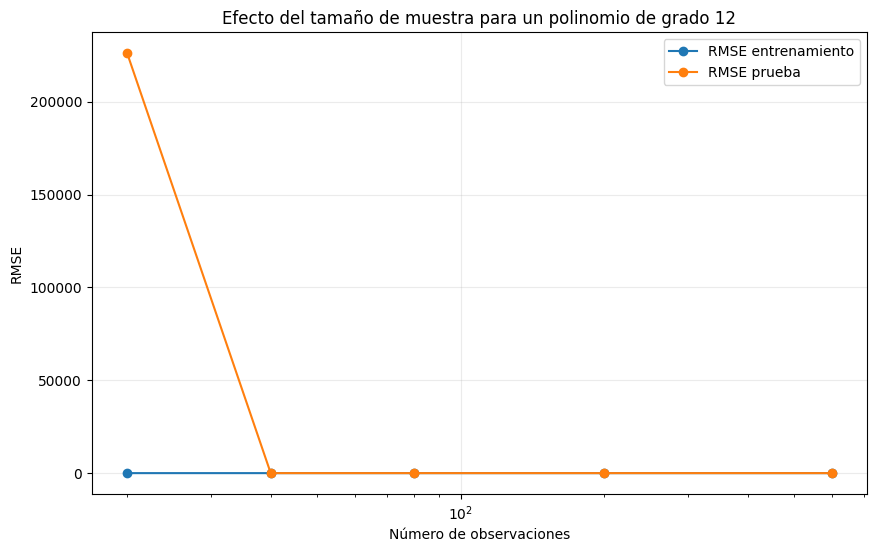

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    sample_size_table["n"],
    sample_size_table["rmse_train"],
    marker="o",
    label="RMSE entrenamiento",
)

plt.plot(
    sample_size_table["n"],
    sample_size_table["rmse_test"],
    marker="o",
    label="RMSE prueba",
)

plt.xlabel("Número de observaciones")
plt.ylabel("RMSE")
plt.title(
    f"Efecto del tamaño de muestra para un polinomio de grado "
    f"{degree_for_sample_size}"
)
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Curvas de aprendizaje

Una curva de aprendizaje muestra cómo cambia el desempeño al aumentar el número de observaciones utilizadas para entrenar.

Nos ayuda a diagnosticar si el problema parece deberse a:

- falta de capacidad;
- alta varianza;
- escasez de datos;
- una brecha persistente entre entrenamiento y validación.

In [16]:
learning_model = build_polynomial_model(degree=8)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=learning_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.15, 1.0, 8),
    cv=5,
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=RANDOM_STATE,
)

train_rmse_scores = -train_scores
validation_rmse_scores = -validation_scores

learning_results = pd.DataFrame({
    "n_entrenamiento": train_sizes,
    "rmse_train_media": train_rmse_scores.mean(axis=1),
    "rmse_train_std": train_rmse_scores.std(axis=1),
    "rmse_validacion_media": validation_rmse_scores.mean(axis=1),
    "rmse_validacion_std": validation_rmse_scores.std(axis=1),
})

learning_results


,n_entrenamiento,rmse_train_media,rmse_train_std,rmse_validacion_media,rmse_validacion_std
0,14,0.1849,0.0141,1.5552,0.7043
1,26,0.2653,0.0299,1.5535,1.1163
2,37,0.3041,0.0361,0.6400,0.4419
3,49,0.3249,0.0249,0.4283,0.0825
4,61,0.3183,0.0223,0.4092,0.0788
5,72,0.3285,0.0200,0.3914,0.0620
6,84,0.3389,0.0179,0.3882,0.0679
7,96,0.3385,0.0140,0.3896,0.0679


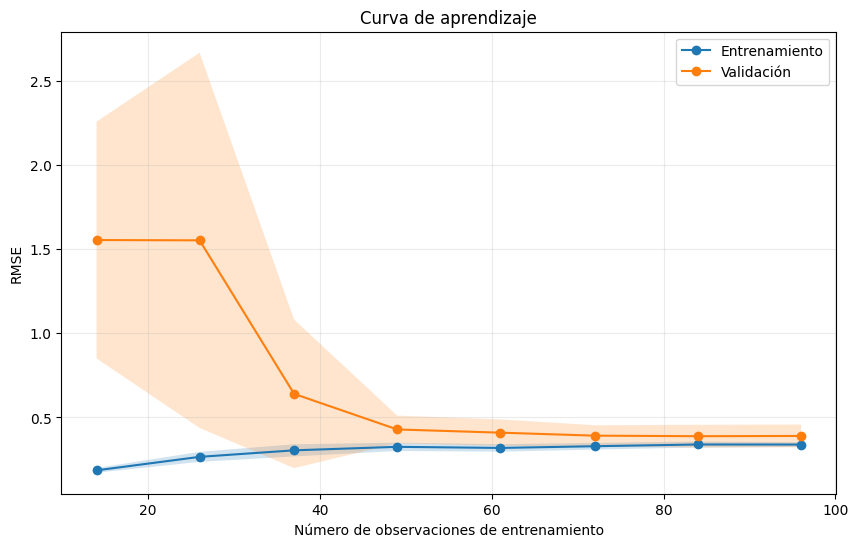

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    learning_results["n_entrenamiento"],
    learning_results["rmse_train_media"],
    marker="o",
    label="Entrenamiento",
)

plt.plot(
    learning_results["n_entrenamiento"],
    learning_results["rmse_validacion_media"],
    marker="o",
    label="Validación",
)

plt.fill_between(
    learning_results["n_entrenamiento"],
    learning_results["rmse_train_media"]
    - learning_results["rmse_train_std"],
    learning_results["rmse_train_media"]
    + learning_results["rmse_train_std"],
    alpha=0.2,
)

plt.fill_between(
    learning_results["n_entrenamiento"],
    learning_results["rmse_validacion_media"]
    - learning_results["rmse_validacion_std"],
    learning_results["rmse_validacion_media"]
    + learning_results["rmse_validacion_std"],
    alpha=0.2,
)

plt.xlabel("Número de observaciones de entrenamiento")
plt.ylabel("RMSE")
plt.title("Curva de aprendizaje")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 10. Diagnóstico rápido

### Underfitting

Suele observarse cuando:

- el error de entrenamiento es alto;
- el error de validación también es alto;
- ambos errores son relativamente cercanos;
- agregar datos no resuelve el problema principal.

Posibles acciones:

- aumentar la capacidad;
- agregar variables informativas;
- introducir transformaciones;
- reducir regularización excesiva.

### Overfitting

Suele observarse cuando:

- el error de entrenamiento es muy bajo;
- el error de validación es considerablemente mayor;
- el desempeño cambia mucho entre muestras.

Posibles acciones:

- reducir complejidad;
- regularizar;
- conseguir más datos;
- mejorar el proceso de validación;
- eliminar variables irrelevantes o con leakage.

## 11. Error frecuente: seleccionar con el conjunto de prueba

En este notebook observamos el test para estudiar visualmente la generalización.

En un flujo correcto:

1. se ajustan modelos con entrenamiento;
2. se seleccionan decisiones usando validación o validación cruzada;
3. se utiliza el test una sola vez para obtener una estimación final.

Revisar repetidamente el test termina adaptando indirectamente las decisiones a ese conjunto.

## 12. Experimentos sugeridos

### Experimento 1

Cambia el ruido de `0.35` a:

- `0.0`
- `0.15`
- `0.7`
- `1.5`

Analiza cómo cambia el grado que parece generalizar mejor.

### Experimento 2

Cambia la proporción de prueba:

- `0.10`
- `0.25`
- `0.50`

¿El ranking de modelos permanece estable?

### Experimento 3

Repite el split con diferentes semillas.  
Registra qué grado obtiene el menor RMSE en cada repetición.

### Experimento 4

Compara curvas de aprendizaje para grados:

- 1
- 3
- 8
- 15

### Experimento 5

Aumenta el número total de observaciones a 1,000.  
¿El modelo de grado alto sigue mostrando la misma inestabilidad?

### Experimento 6

Sustituye la función verdadera por otra relación no lineal y repite el análisis.

## 13. Resumen

En este notebook:

- distinguimos ajuste de entrenamiento y generalización;
- observamos underfitting y overfitting;
- analizamos el error según la complejidad;
- aproximamos empíricamente el sesgo y la varianza;
- estudiamos el efecto del tamaño de muestra;
- construimos curvas de aprendizaje;
- discutimos el uso correcto de entrenamiento, validación y prueba.

La meta no es encontrar el modelo que mejor recuerde los datos disponibles, sino el que capture una estructura que se mantenga sobre observaciones nuevas.